# Minimera makespan i en verkstad med PROC OPTMODEL


## Sammanfattning

En liten cell för diskret tillverkning måste driva fyra detaljer — en **Konsol**, en **Fläns**, ett **Hölje** och en **Axel** — genom en fast sekvens av tre bearbetningsoperationer var, som delar fyra maskiner med enkelkapacitet (**Såg**, **Fräs**, **Borr**, **Slip**). Ingen maskin kan köra två operationer samtidigt, och varje detaljs operationer måste följa sin teknologiska ordning. Vi formulerar det makespan-minimerande schemat som ett blandat heltalsprogram i **PROC OPTMODEL** — starttidsvariabler, precedensvillkor från avslut till start och disjunktiva (big-*M*) icke-överlappsvillkor mellan varje par av operationer som delar en maskin — och löser det till bevisad optimalitet.

MILP-lösaren returnerar en **optimal makespan på 120 minuter** (`Solution Status = Optimal`, `Objective Value = 120`). Det resulterande schemat packar alla tolv operationerna så att varje maskin bearbetar högst en detalj i taget och varje detalj bearbetas Såg/Fräs/Borr före Slip i sin nödvändiga ordning. Två operationer avslutas exakt vid minut 120 — Konsols slipning och Höljes fräsning — så både Slip- och Fräs-maskinen ligger på den kritiska linjen som fastställer schemats längd.

## Datakällor

Alla data definieras i notebooken — inga externa filer eller nätverk.

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | En rad per operation (4 detaljer × 3 operationer). `machine` (1–4) är maskinen som operationen behöver; `dur` är dess bearbetningstid i minuter; `jobname`/`mname` är läsbara detalj- och maskinetiketter. |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODEL-utdata: den optimala start- och slutminuten för varje operation. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` sammanslaget med de lösta tiderna, sorterat efter maskin och sedan start — det mänskligt läsbara schemat. |
| `mk` | 1 | `makespan` | Den realiserade makespanen (senaste sluttiden). |

## Schemaläggningsproblemet

I en **verkstad** (job shop) passerar flera detaljer ("jobb") var och en genom en fast sekvens av operationer, och varje operation körs på en specifik maskin. Två operationer kan inte uppta samma maskin samtidigt (maskinerna är *unära* resurser), och inom en detalj måste operationerna respektera sin teknologiska ordning. Planeraren vill ha starttider för varje operation som hedrar båda reglerna samtidigt som den totala schemalängden — **makespanen** — hålls så liten som möjligt.

Detta är ett klassiskt disjunktivt schemaläggningsproblem. Vi modellerar det som ett blandat heltalsprogram:

- en kontinuerlig-men-heltalig **starttid** `s[o]` för varje operation, och en makespanvariabel `Cmax`;
- **precedens**: operation *k+1* av en detalj startar inte tidigare än operation *k* avslutas;
- **disjunktiv maskinkapacitet**: för varje par av operationer som delar en maskin avgör en binär `y` vilken som går först, och en big-*M*-term stänger av den inaktiva ordningen — så de två operationerna kan aldrig överlappa;
- **målfunktion**: minimera `Cmax`, som tvingas vara minst varje operations sluttid.

PROC OPTMODEL är SAS/OR:s algebraiska modelleringsprocedur; dess MILP-lösare hittar det *bevisbart optimala* kortaste schemat.

> **En anmärkning om PROC CLP.** SAS erbjuder också PROC CLP, en motor för > constraint-logic programming med dedikerad schemaläggningssyntax (aktiviteter, > resurser, precedens). OPTMODEL-MILP-formuleringen här löser det > identiska problemet och returnerar ett optimalitetscertifikat, vilket CLP:s > tillåtlighetssökning inte gör.

## Steg 1 — Definiera verkstadsinstansen

Fyra detaljer, tre operationer var, på fyra maskiner. Varje rad fixerar maskinen en operation behöver och dess bearbetningstid i minuter. En detaljs operationer listas i teknologisk ordning (`opnum` 1, 2, 3).

In [1]:
data jobshop;
    LÄNGD jobname $10 mname $6;
    INDATA op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Konsol  Såg
2  1 2 3 40 Konsol  Borr
3  1 3 4 20 Konsol  Slip
4  2 1 2 35 Fläns   Fräs
5  2 2 3 25 Fläns   Borr
6  2 3 1 15 Fläns   Såg
7  3 1 3 30 Hölje   Borr
8  3 2 1 20 Hölje   Såg
9  3 3 2 45 Hölje   Fräs
10 4 1 1 20 Axel    Såg
11 4 2 2 30 Axel    Fräs
12 4 3 4 25 Axel    Slip
;
KÖR;

PROCEDUR SKRIV data=jobshop noobs ETIKETT;
    TITEL 'Verkstadsinstans: 4 detaljer, 3 operationer var, 4 maskiner';
    VARIABEL op jobname opnum mname dur;
    ETIKETT op="Operation" jobname="Detalj" opnum="Operationsnr" mname="Maskin" dur="Tid (min)";
KÖR;

                              Verkstadsinstans: 4 detaljer, 3 operationer var, 4 maskiner                               

Operation  Detalj  Operationsnr  Maskin  Tid (min)
        1  Konsol             1  Såg            25
        2  Konsol             2  Borr           40
        3  Konsol             3  Slip           20
        4  Fläns              1  Fräs           35
        5  Fläns              2  Borr           25
        6  Fläns              3  Såg            15
        7  Hölje              1  Borr           30
        8  Hölje              2  Såg            20
        9  Hölje              3  Fräs           45
       10  Axel               1  Såg            20
       11  Axel               2  Fräs           30
       12  Axel               3  Slip           25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Steg 2 — Lös det makespan-minimerande schemat med PROC OPTMODEL

OPTMODEL läser instansen, bygger start- och ordningsvariablerna, postar precedens- och disjunktionsvillkoren och minimerar makespanen med sin MILP-lösare. Big-*M*-horisonten `H` är det totala arbetsinnehållet — en säker övre gräns för vilken starttid som helst. Lösaren rapporterar den **optimala** målfunktionen; vi skriver de valda start- och sluttiderna till `sched`.

In [2]:
PROCEDUR optmodel;
    STÄLL_IN OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ data jobshop INTO OPS=[op] job opnum machine dur;

    /* en säker big-M-horisont = totalt arbetsinnehåll */
    num H = sum{o IN OPS} dur[o];

    VARIABEL s{OPS} >= 0 integer;     /* operationens starttid (minuter) */
    VARIABEL Cmax >= 0;               /* makespan */

    /* teknologisk ordning: op k+1 startar efter att op k avslutats */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* makespan dominerar varje operations sluttid */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* disjunktiv maskinkapacitet: för varje operationspar som delar en
       maskin fixerar binär y ordningen; big-M släpper den andra */
    VARIABEL y{a IN OPS, b IN OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE data sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                              Verkstadsinstans: 4 detaljer, 3 operationer var, 4 maskiner                               


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Steg 3 — Sätt samman det läsbara schemat

Slå samman de lösta tiderna tillbaka på detalj- och maskinetiketterna, sortera efter maskin och sedan starttid, och skriv ut schemat. Makespanen är den största sluttiden över alla operationer.

In [3]:
PROCEDUR SORTERA data=jobshop out=jobs2; EFTER op; KÖR;
PROCEDUR SORTERA data=sched   out=sol;   EFTER op; KÖR;

data schedule;
    SAMMANFOGA jobs2 sol;
    EFTER op;
KÖR;

PROCEDUR SORTERA data=schedule; EFTER mname START; KÖR;

PROCEDUR SKRIV data=schedule noobs ETIKETT;
    TITEL 'Optimalt schema: start/slut (minuter) för varje operation';
    VARIABEL jobname opnum mname dur START FINISH;
    ETIKETT jobname="Detalj" opnum="Operationsnr" mname="Maskin" dur="Tid (min)" START="Start (min)" FINISH="Slut (min)";
KÖR;

PROCEDUR MEDELVÄRDEN data=schedule MAX NOPRINT;
    VARIABEL FINISH;
    UTDATA out=mk(TA_BORT=_type_ _freq_) MAX=makespan;
KÖR;

PROCEDUR SKRIV data=mk noobs ETIKETT;
    TITEL 'Minimal makespan (senaste operationsslut, minuter)';
    ETIKETT makespan="Makespan (min)";
KÖR;

                               Optimalt schema: start/slut (minuter) för varje operation                                

Detalj  Operationsnr  Maskin  Tid (min)  Start (min)  Slut (min)
Hölje              1  Borr           30            0          30
Fläns              2  Borr           25           35          60
Konsol             2  Borr           40           60         100
Fläns              1  Fräs           35            0          35
Axel               2  Fräs           30           35          65
Hölje              3  Fräs           45           75         120
Axel               3  Slip           25           65          90
Konsol             3  Slip           20          100         120
Axel               1  Såg            20            0          20
Konsol             1  Såg            25           20          45
Hölje              2  Såg            20           45          65
Fläns              3  Såg            15           65          80

                                


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Steg 4 — Visualisera schemat

Vi ger varje operation en ordningsföljd i en **plats** (sorterad efter maskin, sedan start) och ritar dess tidsfönster som en flytande stapel: stapeln sträcker sig från operationens startminut till dess slutminut. Platserna 1–3 är Borr, 4–6 Fräs, 7–8 Slip och 9–12 Såg. Tabellen direkt nedanför namnger detaljen i varje plats, så diagrammet och tabellen läses tillsammans. Staplar på samma maskin överlappar aldrig i tid — det disjunktiva villkoret synliggjort.

                               Schema efter plats (platsordning matchar diagrammet nedan)                               

Plats  Maskin  Detalj  Start (min)  Slut (min)
    1  Borr    Hölje             0          30
    2  Borr    Fläns            35          60
    3  Borr    Konsol           60         100
    4  Fräs    Fläns             0          35
    5  Fräs    Axel             35          65
    6  Fräs    Hölje            75         120
    7  Slip    Axel             65          90
    8  Slip    Konsol          100         120
    9  Såg     Axel              0          20
   10  Såg     Konsol           20          45
   11  Såg     Hölje            45          65
   12  Såg     Fläns            65          80

                               Schema efter plats (platsordning matchar diagrammet nedan)                               




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


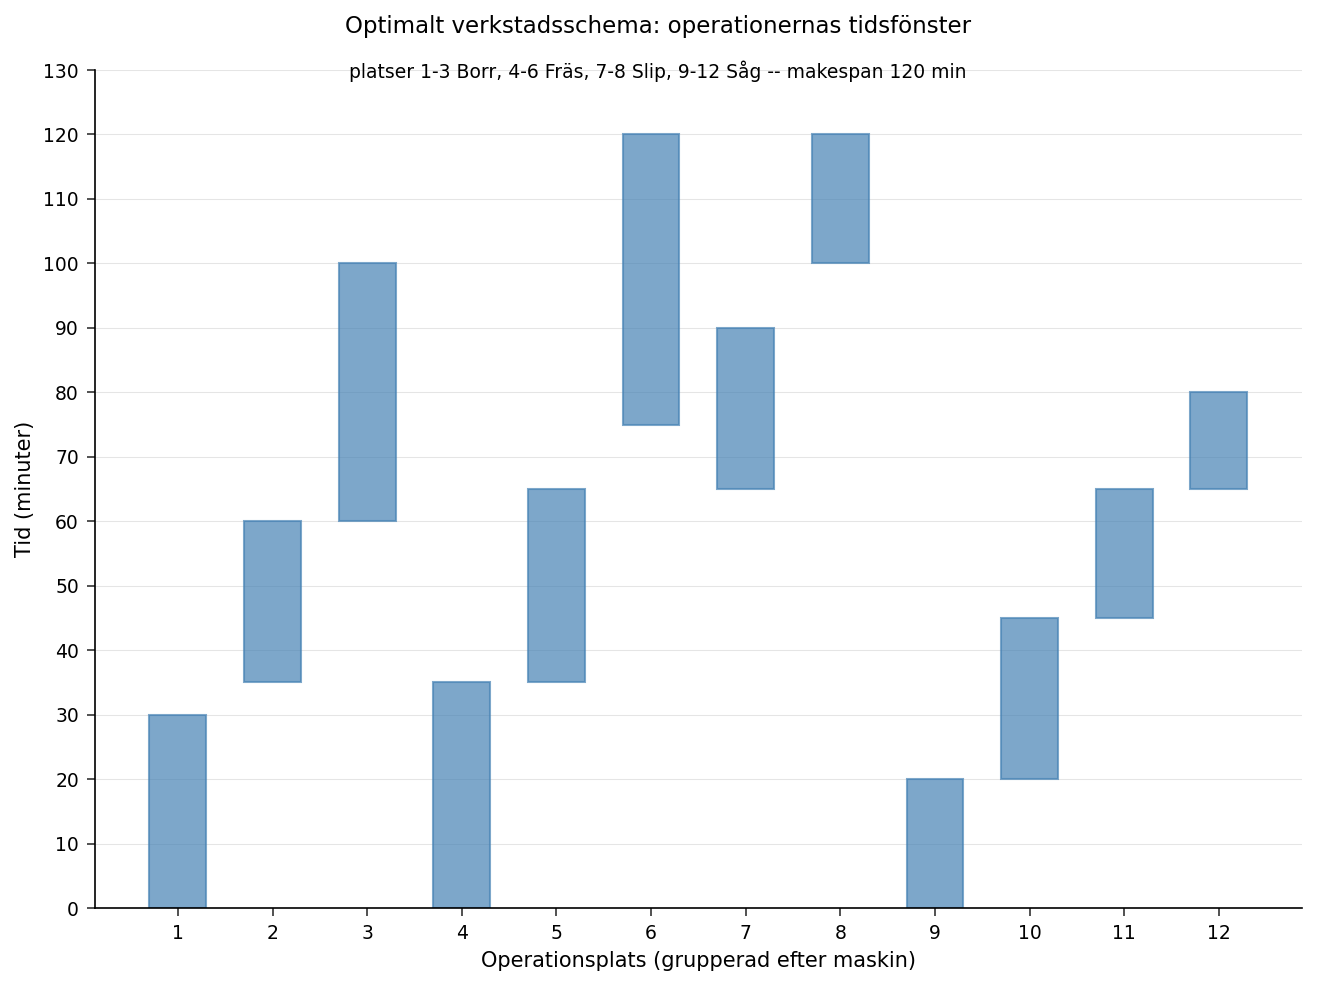

In [4]:
data ganttdata;
    STÄLL_IN schedule;
    slot + 1;
KÖR;

PROCEDUR SKRIV data=ganttdata noobs ETIKETT;
    TITEL 'Schema efter plats (platsordning matchar diagrammet nedan)';
    VARIABEL slot mname jobname START FINISH;
    ETIKETT slot="Plats" mname="Maskin" jobname="Detalj" START="Start (min)" FINISH="Slut (min)";
KÖR;

PROCEDUR SGPLOT data=ganttdata noautolegend;
    TITEL 'Optimalt verkstadsschema: operationernas tidsfönster';
    title2 'platser 1-3 Borr, 4-6 Fräs, 7-8 Slip, 9-12 Såg -- makespan 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ETIKETT='Operationsplats (grupperad efter maskin)' integer
          VALUES=(1 TILL 12 EFTER 1);
    YAXIS ETIKETT='Tid (minuter)' grid VALUES=(0 TILL 130 EFTER 10);
KÖR;
TITEL;

## Tolka resultaten

- **Optimalitet.** MILP-lösaren returnerade `Solution Status = Optimal` med `Objective Value = 120`, så **120 minuter är den bevisbart kortaste möjliga makespanen** för denna instans — inget schema kan avslutas tidigare. Detta certifikat är vad den matematiska programmeringsformuleringen ger dig framför en ren tillåtlighetssökning.

- **Schemat hedrar varje villkor.** Läser man tabellen per maskin överlappar inga två operationer på samma maskin (t.ex. på Såg: Axel 0–20, Konsol 20–45, Hölje 45–65, Fläns 65–80), och varje detalj körs i teknologisk ordning (t.ex. Hölje: Borr 0–30, sedan Såg 45–65, sedan Fräs 75–120). Diagrammet med flytande staplar visar samma sak: inom varje maskins platsband kaklar tidsfönstren utan kollision.

- **Vad som fastställer schemalängden.** Två operationer avslutas exakt vid minut 120 — Konsols Slip (plats 8) och Höljes Fräs (plats 6). Båda vidrör makespanen, så Grind- och Mill-maskinerna ligger på den kritiska linjen; att minska makespanen ytterligare skulle kräva att man ändrar instansen själv (snabbare operationer, en extra maskin eller lättad precedens), inte enbart att man ordnar om sekvensen.

- **Hur det skalar.** Formuleringen växer naturligt: lägg till en maskin som ett annat värde av `machine`, lägg till detaljer som fler rader i `jobshop`, eller modellera frisläppnings- och förfallodatum genom att begränsa `s[o]` och lägga till förfallovillkor. Att låta en maskin köra flera jobb samtidigt (kapacitet >1) ersätter den parvisa disjunktionen med ett kumulativt resursvillkor. Samma OPTMODEL-MILP hanterar då rikare verkstadsgolvregler utan att byta lösare.